# Model Training

### 1.1 Import Data and Required Packages

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
#import models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
#import metries
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import RandomizedSearchCV

#### Importing data from csv

In [36]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Preparing X and y variable

In [37]:
X = df.drop(columns=['math_score'])

In [38]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [39]:
y = df['math_score']
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

#### Train and test split

In [40]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#### Features preprocessing(One hot Encoding, Standardization)

In [41]:
print(df.shape)

(1000, 8)


In [42]:
num_features = X.select_dtypes(exclude='str').columns
cat_features = X.select_dtypes(include='str').columns

numerical_transformer = StandardScaler()
oh_encoder = OneHotEncoder()

column_transformer = ColumnTransformer(
    [('onehotencoder',oh_encoder,cat_features),
    ('Scaler',numerical_transformer,num_features)]
)

In [43]:
X_train_transformed = column_transformer.fit_transform(X_train)
X_test_transformed = column_transformer.transform(X_test)
print(X_train_transformed[:5])

[[ 1.          0.          0.          0.          0.          1.
   0.          0.          0.          0.          1.          0.
   0.          0.          1.          0.          1.          0.03079054
   0.43405338]
 [ 1.          0.          0.          0.          1.          0.
   0.          0.          1.          0.          0.          0.
   0.          1.          0.          1.          0.          0.9302895
   0.96470125]
 [ 1.          0.          0.          0.          0.          1.
   0.          0.          0.          0.          0.          1.
   0.          1.          0.          0.          1.          1.34544287
   1.1636942 ]
 [ 0.          1.          0.          0.          1.          0.
   0.          0.          0.          0.          1.          0.
   0.          1.          0.          0.          1.         -0.17678614
  -0.16292548]
 [ 0.          1.          0.          0.          0.          0.
   1.          0.          0.          1.          

In [44]:
X_train_transformed.shape

(800, 19)

### Create an evaluate function

In [45]:
def eval_model(true, predict):
    mae = mean_absolute_error(true, predict)
    mse = mean_absolute_error(true, predict)
    rmse = root_mean_squared_error(true, predict)
    r2= r2_score(true, predict)
    return mae, mse, rmse, r2


#### Models comparision

In [46]:
models = {
    "LinearRegression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "K-Neighbors Regressor":KNeighborsRegressor(),
    "Decision Tree":DecisionTreeRegressor(),
    "Random Forest Regressor" : RandomForestRegressor(),
    "XGB Regressor" : XGBRegressor(),
    "AdaBoost Regressor":AdaBoostRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=False),
}

model_list = []
r2_list = []

for name,model in models.items():
    model.fit(X_train_transformed,y_train)

    #make train and test predictions
    y_train_pred = model.predict(X_train_transformed)
    y_test_pred = model.predict(X_test_transformed)

    #evalutions of the models
    train_mae, train_mse, train_rmse, train_r2 = eval_model(y_train,y_train_pred)
    test_mae, test_mse, test_rmse, test_r2 = eval_model(y_test,y_test_pred)

    print(name)
    model_list.append(name)

    print('Model performance for Training set')
    print("- Mean Squared Error: {:.4f}".format(train_mse))
    print("- Root Mean Squared Error: {:.4f}".format(train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(train_mae))
    print("- R2 Score: {:.4f}".format(train_r2))

    print('----------------------------------')
        
    print('Model performance for Test set')
    print("- Mean Squared Error: {:.4f}".format(train_mse))
    print("- Root Mean Squared Error: {:.4f}".format(test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(test_mae))
    print("- R2 Score: {:.4f}".format(test_r2))
    r2_list.append(test_r2)

    
    print('='*35)
    print('\n')

LinearRegression
Model performance for Training set
- Mean Squared Error: 4.2667
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Mean Squared Error: 4.2667
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Lasso
Model performance for Training set
- Mean Squared Error: 5.2053
- Root Mean Squared Error: 6.5925
- Mean Absolute Error: 5.2053
- R2 Score: 0.8072
----------------------------------
Model performance for Test set
- Mean Squared Error: 5.2053
- Root Mean Squared Error: 6.5173
- Mean Absolute Error: 5.1557
- R2 Score: 0.8254


Ridge
Model performance for Training set
- Mean Squared Error: 4.2650
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Mean Squared Error: 4.2650
- Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
- R2 Score:

## Result

In [47]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880592
0,LinearRegression,0.880433
5,Random Forest Regressor,0.852879
8,CatBoost Regressor,0.851831
7,AdaBoost Regressor,0.847042
6,XGB Regressor,0.827797
1,Lasso,0.825446
3,K-Neighbors Regressor,0.785944
4,Decision Tree,0.754334


# Lineaar Regression

In [48]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train_transformed, y_train)
y_pred = lin_model.predict(X_test_transformed)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.04


### Plot y_pred and y_test

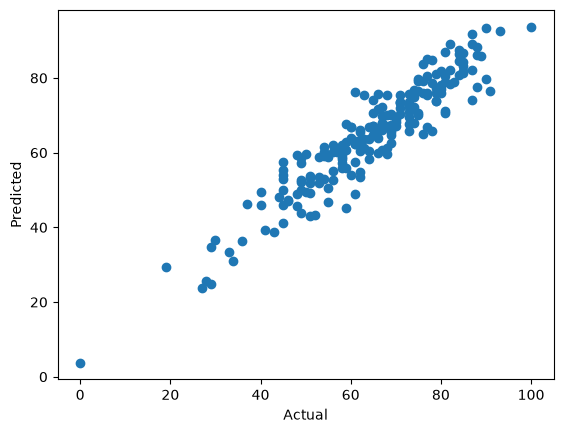

In [49]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

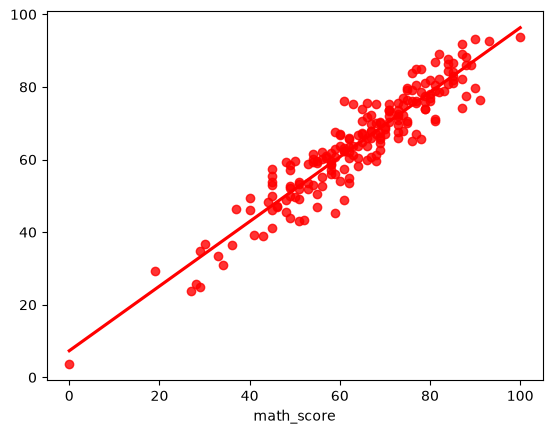

In [50]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [51]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
